# AI Attitudes Survey Widgets

This notebook contains a number of 'widgets' (in other words, code examples) that you can use to analyze and describe the AI Attitudes Survey.

## Preliminaries

Run the code cell to load and clean the data and import necessary libraries. This code renames columns and drops unneeded columns.

Run this code **before** running any of the widgets in this notebook.

In [36]:
from datetime import date
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob, Word
from wordcloud import WordCloud

file = "/home/shared/AI_Attitudes.csv"
survey = pd.read_csv(file)

# Rename and drop columns
survey.columns=['ID', 'Start', 'End', 'Email', 'Name', 'Last Edit', 'Age', 'Gender', 'Excited', 'Why Excited', 'Concerned', 'Why Concerned', 'Use Freq', 'How Used', 'Tools', 'Report']
survey.drop(columns=['Email', 'Name', 'Last Edit', 'Report'], inplace=True)
survey

# Some recoding using np.select()
# Firstly, create a Net Excited-Concerned score (Net E-C) based on Excited - Concerned
# Then recode age into ascending numerical values so we can order output later
survey['Net E-C'] = survey['Excited'] - survey['Concerned']
conditions = [survey['Net E-C']>0, survey['Net E-C']==0, survey['Net E-C']<0]
values = ['More excited than concerned', 'Equally excited and concerned', 'More concerned than excited']
survey['Net E-C Cat'] = np.select(conditions, values, default='')
conditions = [survey['Age']=='Under 18', survey['Age']=='18-24', survey['Age']=='25-34', survey['Age']=='35-44', survey['Age']=='45-54', survey['Age']=='55 or over', survey['Age']=='Prefer not to say']
values = [0, 1, 2, 3, 4, 5, 6]
survey['Age Code'] = np.select(conditions, values, default=0)
survey

,ID,Start,End,Age,Gender,Excited,Why Excited,Concerned,Why Concerned,Use Freq,How Used,Tools,Net E-C,Net E-C Cat,Age Code
0,11,2/20/26 9:26:30,2/20/26 9:28:20,45-54,Male,4,Making coding easier,9,Concerned about impact on employment prospects...,Several times a day,"search, finding out how to code things.",Microsoft Copilot;Chat GPT;Google Gemini;,-5,More concerned than excited,4
1,12,2/20/26 9:52:31,2/20/26 10:03:38,45-54,Female,8,It simplifies otherwise manual tasks and it’s ...,8,It has become a crutch for me - I have come to...,Several times a day,See above.,Chat GPT;Claude (Anthropic);Microsoft Copilot;,0,Equally excited and concerned,4
2,13,2/20/26 11:52:56,2/20/26 11:54:14,55 or over,Female,7,NaN,4,NaN,A few times a week,Answer search questions,Chat GPT;Microsoft Copilot;,3,More excited than concerned,5
3,14,2/20/26 11:55:10,2/20/26 12:06:45,25-34,Male,10,The possibilities that become more probable wh...,10,Dependency on AI to solve simple problems we s...,Several times a day,"Resume, Explain Complex Code, Math Tutor, draf...",Notebook LM;Google Gemini;Perplexity AI;Claude...,0,Equally excited and concerned,2
4,15,2/20/26 13:38:13,2/20/26 13:39:51,45-54,Female,2,NaN,8,"Outsourced thinking, loss of human creativity ...",A few times a week,Analyse data.,Notebook LM;Chat GPT;Microsoft Copilot;,-6,More concerned than excited,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,119,3/4/26 10:13:23,3/4/26 10:15:23,25-34,Female,8,Being able to use AI as a tool to further my k...,4,The movie IRobot,Several times a day,"Spell check homework, answer questions",Google Gemini;Grammarly;Claude (Anthropic);Cha...,4,More excited than concerned,2
109,120,3/4/26 11:00:36,3/4/26 11:18:28,25-34,Female,5,I feel neutral about the use of AI in people’s...,6,"Up until about 3 weeks ago, I did not think of...",A few times a week,I actually use it mainly for health reasons. I...,Chat GPT;Google Gemini;,-1,More concerned than excited,2
110,121,3/4/26 11:19:28,3/4/26 11:23:29,45-54,Female,8,I can do work faster since i write many emails.,9,Water usage and young people using there brain...,About once a day,Help with items at work!,Chat GPT;Microsoft Copilot;Google Gemini;,-1,More concerned than excited,4
111,122,3/4/26 11:24:48,3/4/26 11:29:46,35-44,Female,8,I like to use AI for career development as wel...,6,I do worry about how it affects the environment.,Several times a day,"I use it for resume, cover letters, career pla...",Chat GPT;Perplexity AI;Google Gemini;,2,More excited than concerned,3


## Summary Statistics

The tools below give you examples of how to create summary statistics using the `describe()` method for numerical data and how to compare summary statistics for different subgroups of the dataset. For example:

- `survey.describe()` will give you summary stats for all numerical values
- `survey[survey['Gender']=='Male'].describe()` will give you summary stats just for the people who gave their gender as male.
- `survey.groupby('Age')['Excited'].describe()` will give you summary stats by age group, just for the 'Excited' variable.

In [32]:
# Overall summary stats
survey.describe()

,ID,Excited,Concerned,Net E-C,Age Code
count,113.00000,113.000000,113.000000,113.00000,113.000000
mean,67.00000,5.663717,6.867257,-1.20354,2.575221
std,32.76431,2.734079,2.425697,4.36741,1.438038
min,11.00000,1.000000,1.000000,-9.00000,0.000000
25%,39.00000,3.000000,5.000000,-5.00000,1.000000
50%,67.00000,5.000000,7.000000,-1.00000,2.000000
75%,95.00000,8.000000,9.000000,2.00000,4.000000
max,123.00000,10.000000,10.000000,9.00000,6.000000


In [33]:
# Summary stats for a subgroup 
survey[survey['Gender']=='Male'].describe()

,ID,Excited,Concerned,Net E-C,Age Code
count,50.00000,50.000000,50.00000,50.000000,50.000000
mean,60.12000,6.140000,6.44000,-0.300000,2.480000
std,28.56117,2.857214,2.54077,4.315374,1.528505
min,11.00000,1.000000,1.00000,-9.000000,0.000000
25%,34.50000,4.000000,4.00000,-4.000000,1.000000
50%,59.00000,6.500000,7.00000,0.000000,2.000000
75%,80.50000,8.750000,8.00000,2.750000,4.000000
max,123.00000,10.000000,10.00000,8.000000,5.000000


In [ ]:
# groupby() allows you to examine statistics split across categories
survey.groupby('Age')['Excited'].describe()

## Crosstabs

A crosstab (short for cross tabulation) gives you a count of how many respondents fall into particular categories, based on two or more data columns.

For example, the crosstab below, gives you a table showing how many people fall into each combination of 'Gender' and 'Age' categories.

`pd.crosstab(survey['Gender'], survey['Age'])`

In [38]:
# A crosstab allows you to compare one column based on categories in other columns
# In this example, we can see that there are 12 males between the ages of 18-24, for example
pd.crosstab(survey['Gender'], survey['Age'],margins=True, margins_name="Total")

Age,18-24,25-34,35-44,45-54,55 or over,Prefer not to say,Under 18,Total
Gender,,,,,,,,
Female,13,17,12,11,6,1,1,61
Male,12,15,6,6,8,0,3,50
Other,0,1,0,0,0,0,0,1
Prefer not to say,0,1,0,0,0,0,0,1
Total,25,34,18,17,14,1,4,113


## Histograms

Histograms allow you to see the distribution of numerical data. The horizontal axis shows values for the numerical data and the vertical axes gives you frequencies.

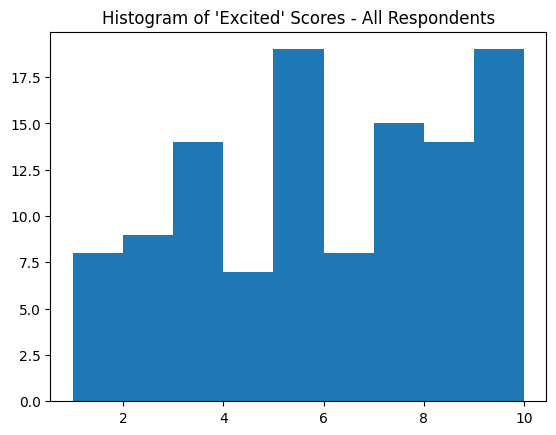

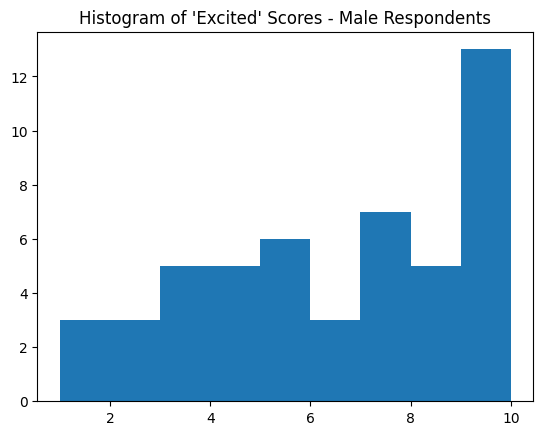

In [40]:
# This first histogram shows the distribution of excited scores
plt.hist(survey['Excited'], bins=np.arange(1, 11))
plt.title("Histogram of 'Excited' Scores - All Respondents")
plt.show()

# This does the same thing, but just for males
plt.hist(survey[survey['Gender']=='Male']['Excited'], bins=np.arange(1, 11))
plt.title("Histogram of 'Excited' Scores - Male Respondents")
plt.show()

## Using Value Counts

Suppose we want to know how many people are in each age category. The `value_counts()` method allows use to do this. 

A convenient way to use `value_counts()` is to put the result into a new dataframe. This allows you to graph the data easily.

Sometimes the counts are not sorted in the way you want, so you need to find a way to sort them.

In [41]:
#  This code puts the 'Age' value counts into a new dataframe
# Because value_counts returns values in no particular order, we sort by 'Age Code' to order the data correctly
age_distr = survey['Age Code'].value_counts()
age_distr = pd.DataFrame(age_distr)
age_distr.reset_index(inplace=True)
age_distr.sort_values(by='Age Code', inplace=True)
age_distr

,Age Code,count
5,0,4
1,1,25
0,2,34
2,3,18
3,4,17
4,5,14
6,6,1


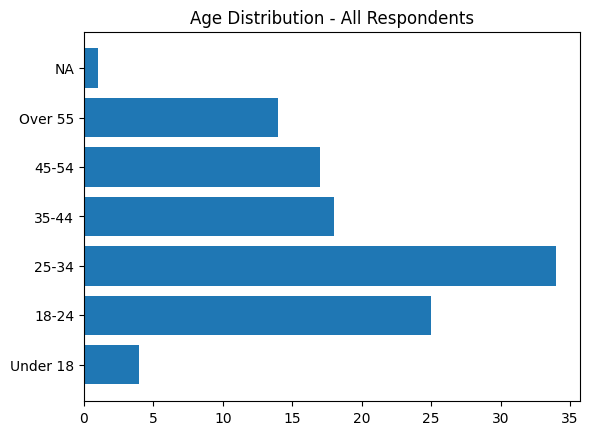

In [44]:
# Now we can create a bar chart using the data above
# We just need to create a list of categories for age that correspond with our value counts
age_cats = ['Under 18', '18-24', '25-34', '35-44', '45-54', 'Over 55', 'NA']
plt.barh(age_cats, age_distr['count'])
plt.title("Age Distribution - All Respondents")
plt.show()

## Comparing Two or More Groups

Some times we want to look at one variable across two or more groups. For example, we might want to look at the distribution of ages for males and females.

Depending on the type of data, there are several ways to do this:

- A bar chart with two or more sets of bars
- Separate, side-by-side plots
- A side-by-side boxplot (for numerical data)

The examples below show how to do all of these.

### Bar Charts

Bar charts are good for displaying categorical data. You can display categorical data for two groups on the same chart using multiple bars.

In [49]:
# Bar Charts with two sets of columns

# Split whole dataset into 'Male' and "Female' sections
survey_m = survey[survey['Gender']=='Male']
survey_f = survey[survey['Gender']=='Female']

# Create a value count for "Age Code" for male respondents
ages_m = survey_m['Age Code'].value_counts()
ages_m = pd.DataFrame(ages_m)
ages_m.reset_index(inplace=True)
ages_m.sort_values(by='Age Code', inplace=True)
ages_m.loc[len(ages_m)]=[6, 0]
ages_m

,Age Code,count
5,0,3
1,1,12
0,2,15
4,3,6
3,4,6
2,5,8
6,6,0


In [50]:
# Create a value count for 'Age Code' for female respondents
ages_f= survey_f['Age Code'].value_counts()
ages_f = pd.DataFrame(ages_f)
ages_f.reset_index(inplace=True)
ages_f.sort_values(by='Age Code', inplace=True)
ages_f

,Age Code,count
5,0,1
1,1,13
0,2,17
2,3,12
3,4,11
4,5,6
6,6,1


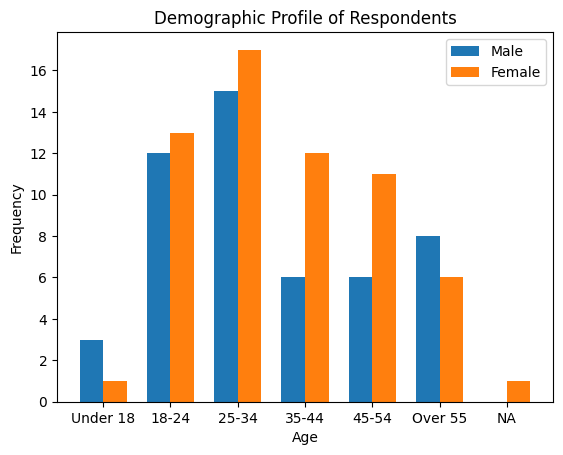

In [51]:
# Now we can create a single bar chart that shows the distribution of ages for males and females
width = 0.35  # the width of the bars

x = np.arange(len(age_cats))
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, ages_m['count'], width, label='Male')
rects2 = ax.bar(x + width/2, ages_f['count'], width, label='Female')

ax.set_ylabel('Frequency')
ax.set_xlabel('Age')
ax.set_title('Demographic Profile of Respondents')
ax.set_xticks(x, age_cats)
ax.legend()
plt.show()

### Side By Side Plots
|
An alternative, that may be better in some cases, is to display two separate graphs or charts next to each other. The Python code to do this is shown below.

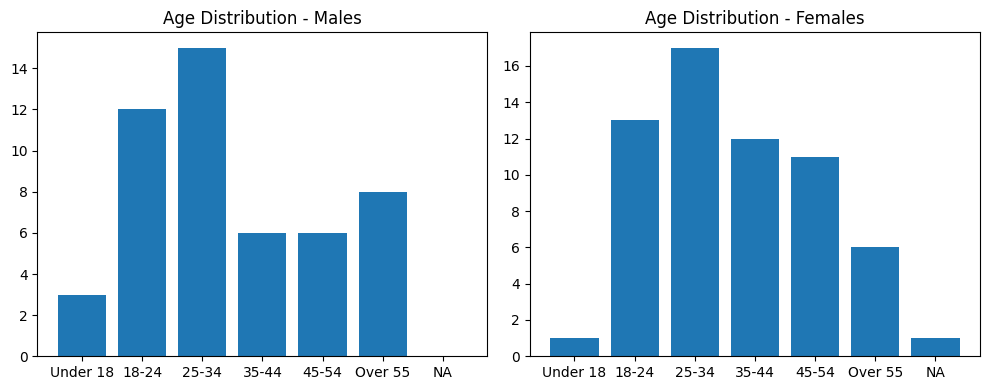

In [56]:
# Create 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot on the first (left) axis
ax1.bar( age_cats,ages_m['count'])
ax1.set_title("Age Distribution - Males")

# Plot on the second (right) axis
ax2.bar( age_cats,ages_f['count'])
ax2.set_title("Age Distribution - Females")

plt.tight_layout() # Prevents overlapping labels
plt.show()


### Box Plots

Side-by-side box plots are a good way to compare numerical data for different groups. With box plots you can easily compare more than two groups.

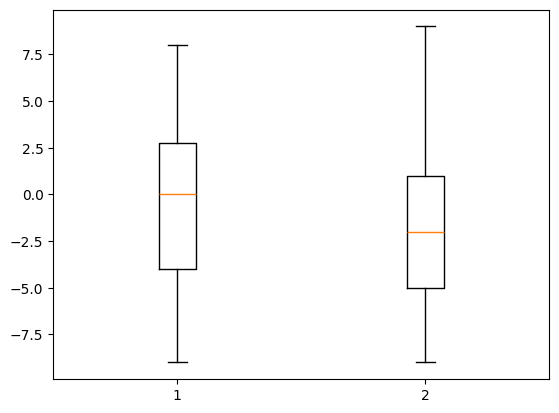

In [15]:
# Here we compare the net excited-concerned score for males and females
plt.boxplot([survey_m['Net E-C'], survey_f['Net E-C']])
plt.show()